#Habitat-sim Basics for Navigation

The Habitat platform relies on a number of key abstractions that model the domain of embodied agents and tasks that can be carried out in three-dimensional indoor simulation environments.

- **Agent**: a virtually embodied agent (e.g., a robot) with a suite of Sensors. Can observe the environment and is capable of taking actions that change agent or environment state.
- **Sensor**: associated with a specific Agent, capable of returning observation data from the environment at a specified frequency.
- **Scene**: a 3D environment containing a scene mesh, objects, Agents, and Sensors.
- **SceneGraph**: a hierarchical representation of a Scene that organizes the environment into regions and objects. Can be programmatically manipulated. All Scene components are present on the SceneGraph.
- **Simulator**: an instance of a simulator backend. Given actions for a set of configured Agents and SceneGraphs, can update the state of the Agents and SceneGraphs, and provide observations for all active Sensors possessed by the Agents.

This tutorial covers the basics of using Habitat-sim for navigation tasks, including:
- configuration of a Simulator, Sensors, and Agents.
- taking actions and retrieving observations
- pathfinding and navigation on the NavMesh

In [1]:
# @title Colab Setup and Imports { display-mode: "form" }
# @markdown (double click to see the code)

import math
import os
import random
import sys
import torch.nn.functional as F
import git
import imageio
import magnum as mn
import numpy as np

%matplotlib inline
from matplotlib import pyplot as plt

# function to display the topdown map
from PIL import Image

import habitat_sim
from habitat_sim.utils import common as utils
from habitat_sim.utils import viz_utils as vut
#blip2
import numpy as np
import torch
from PIL import Image
from lavis.models import load_model_and_preprocess
%cd /content/habitat-sim

if "google.colab" in sys.modules:
    # This tells imageio to use the system FFMPEG that has hardware acceleration.
    os.environ["IMAGEIO_FFMPEG_EXE"] = "/usr/bin/ffmpeg"

repo = git.Repo(".", search_parent_directories=True)
dir_path = repo.working_tree_dir
%cd $dir_path
data_path = os.path.join(dir_path, "data")
# @markdown Optionally configure the save path for video output:
output_directory = "video_output"  # @param {type:"string"}
output_path = os.path.join(dir_path, output_directory)
if not os.path.exists(output_path):
    os.mkdir(output_path)

/home/gary/miniconda3/envs/vlfm_3.9/lib/python3.9/site-packages/fairscale/experimental/nn/offload.py:19: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_fwd(orig_func)  # type: ignore
/home/gary/miniconda3/envs/vlfm_3.9/lib/python3.9/site-packages/fairscale/experimental/nn/offload.py:30: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_bwd(orig_func)  # type: ignore


[Errno 2] No such file or directory: '/content/habitat-sim'
/home/gary/vlfm
/home/gary/vlfm


In [2]:
# @title Define Observation Display Utility Function { display-mode: "form" }

# @markdown A convenient function that displays sensor observations with matplotlib.

# @markdown (double click to see the code)


# Change to do something like this maybe: https://stackoverflow.com/a/41432704
def display_sample(rgb_obs, semantic_obs=np.array([]), depth_obs=np.array([])):
    from habitat_sim.utils.common import d3_40_colors_rgb

    rgb_img = Image.fromarray(rgb_obs, mode="RGBA")

    arr = [rgb_img]
    titles = ["rgb"]
    if semantic_obs.size != 0:
        semantic_img = Image.new("P", (semantic_obs.shape[1], semantic_obs.shape[0]))
        semantic_img.putpalette(d3_40_colors_rgb.flatten())
        semantic_img.putdata((semantic_obs.flatten() % 40).astype(np.uint8))
        semantic_img = semantic_img.convert("RGBA")
        arr.append(semantic_img)
        titles.append("semantic")

    if depth_obs.size != 0:
        depth_img = Image.fromarray((depth_obs / 10 * 255).astype(np.uint8), mode="L")
        arr.append(depth_img)
        titles.append("depth")

    plt.figure(figsize=(12, 8))
    for i, data in enumerate(arr):
        ax = plt.subplot(1, 3, i + 1)
        ax.axis("off")
        ax.set_title(titles[i])
        plt.imshow(data)
    plt.show(block=False)


if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser()
    parser.add_argument("--no-display", dest="display", action="store_false")
    parser.add_argument("--no-make-video", dest="make_video", action="store_false")
    parser.set_defaults(show_video=True, make_video=True)
    args, _ = parser.parse_known_args()
    show_video = args.display
    display = args.display
    do_make_video = args.make_video
else:
    show_video = False
    do_make_video = False
    display = False

# import the maps module alone for topdown mapping
if display:
    from habitat.utils.visualizations import maps

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


# "Hello, World!"

Habitat simulator for navigation consists of **3** important concepts:
- configurable embodied agents
- multiple sensors
- Scene: generic 3D dataset handling (e.g., Matterport, Gibson, and Replica datasets).

In the 1st example, we demonstrate how to setup 1 agent with only 1 sensor (RGB visual sensor), place it in a scene, instruct it to navigate and collect the observations.

### Basic settings

To begin with, we specify a scene we are going to load, designate a default agent, and describe a couple of basic sensor parameters, such as the type, position, resolution of the obeservation (width and height).

In [3]:
# This is the scene we are going to load.
# we support a variety of mesh formats, such as .glb, .gltf, .obj, .ply
#test_scene = "./data/scene_datasets/mp3d_example/17DRP5sb8fy/17DRP5sb8fy.glb"
test_scene =  "/home/gary/vlfm/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.glb"

sim_settings = {
    "scene": test_scene,
    # "scene_dataset": "./data/scene_datasets/mp3d_example/mp3d.scene_dataset_config.json",  # Scene path
    "scene_dataset": "default",  # Scene path
    "default_agent": 0,  # Index of the default agent
    "sensor_height": 0.88,  # Height of sensors in meters, relative to the agent
    "width": 640,  # Spatial resolution of the observations
    "height": 480, #解析度
}

### Configurations for the simulator

To run the simulator, we need to create a configuration that are understandable by our simulator.\
Such a configuration consists of **2** parts:
- **One for the simulator backend.** It specifies parameters that are required to start and run the simulator. For example, the scene to be loaded, whether to load the semantic mesh, to enable physics or not. (Details: [code](https://github.com/facebookresearch/habitat-sim/blob/5820e1adc3ab238d2f564241d4705da5755542c9/src/esp/sim/Simulator.h#L44))
- **One for the agent.** It describes parameters to initialize an agent, such as height, mass, as well as the configs for the attached sensors. User can also define the amount of displacement e.g., in a forward action and the turn angle.
(Details: [code](https://github.com/facebookresearch/habitat-sim/blob/5820e1adc3ab238d2f564241d4705da5755542c9/src/esp/agent/Agent.h#L52))

In [4]:
# This function generates a config for the simulator.
# It contains two parts:
# one for the simulator backend
# one for the agent, where you can attach a bunch of sensors
def make_simple_cfg(settings):
    # simulator backend
    sim_cfg = habitat_sim.SimulatorConfiguration()
    sim_cfg.scene_id = settings["scene"]
    sim_cfg.scene_dataset_config_file = settings.get("scene_dataset", "default")

    # agent
    agent_cfg = habitat_sim.agent.AgentConfiguration()

    # In the 1st example, we attach only one sensor,
    # a RGB visual sensor, to the agent
    rgb_sensor_spec = habitat_sim.CameraSensorSpec()
    rgb_sensor_spec.uuid = "color_sensor"
    rgb_sensor_spec.sensor_type = habitat_sim.SensorType.COLOR
    rgb_sensor_spec.resolution = [settings["height"], settings["width"]]
    rgb_sensor_spec.position = [0.0, settings["sensor_height"], 0.0]
    rgb_sensor_spec.sensor_subtype = habitat_sim.SensorSubType.PINHOLE


    agent_cfg.sensor_specifications = [rgb_sensor_spec]

    return habitat_sim.Configuration(sim_cfg, [agent_cfg])


cfg = make_simple_cfg(sim_settings)

### Create a simulator instance

In [5]:
try:  # Needed to handle out of order cell run in Colab
    sim.close()
except NameError:
    pass
sim = habitat_sim.Simulator(cfg)

[23:42:54:079386]:[Assets] ResourceManager.cpp(355)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SceneInstanceAttributes-provided name : /home/gary/vlfm/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.scn  nor constructed filename : /home/gary/vlfm/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/info_semantic.json 

[23:42:53:969237]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Dataset>: Proposing JSON name : default.scene_dataset_config.json from original name : default| This file does not exist.
[23:42:53:969309]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (capsule3DSolid:capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
[23:42:53:969332]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[23:42:53:969346]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (coneSolid:coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoords_false_useTangents_false_capEnd_true) created and registered.
[23:42:53:969358]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (coneWireframe:coneWireframe_s

exist on disk.
[23:42:54:892463]:[Sim] Simulator.cpp(478)::instanceStageForSceneAttributes : 
---
The active scene does not contain semantic annotations : activeSemanticSceneID_ = 0  
---


1]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (uvSphereSolid:uvSphereSolid_rings_8_segments_16_useTexCoords_false_useTangents_false) created and registered.
[23:42:53:969452]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (uvSphereWireframe:uvSphereWireframe_rings_16_segments_32) created and registered.
[23:42:53:969461]:[Metadata] AssetAttributesManager.cpp(112)::AssetAttributesManager : Built default primitive asset templates : 12
[23:42:53:969606]:[Metadata] SceneDatasetAttributesManager.cpp(37)::createObject : File (default) not found, so new default dataset attributes created  and registered.
[23:42:53:969613]:[Metadata] MetadataMediator.cpp(120)::createSceneDataset : Dataset default successfully created.
[23:42:53:969625]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Physics Manager>: Proposing JSON name : ./data/default.physics_config.json from original name : ./data/default.physics_confi

### Initialize the agent

After we initialize the simulator, we could put the agent in the scene, set and query its state, such as position and orientation.

In [6]:
# initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = np.array([-3, 0.0, 0.0])  # in world space
agent.set_state(agent_state)

# Get agent state
agent_state = agent.get_state()
print("agent_state: position", agent_state.position, "rotation", agent_state.rotation)

agent_state: position [-3.  0.  0.] rotation quaternion(1, 0, 0, 0)


In [7]:
from vlfm.vlm.blip2itm import BLIP2ITMClient
class BLIP2Matcher:
    def __init__(self):
        print("Loading BLIP2 model...")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model, self.vis_processors, self.text_processors = load_model_and_preprocess(
            name="blip2_image_text_matching",
            model_type="pretrain",
            is_eval=True,
            device=self.device,
        )
        print("✓ BLIP2 loaded!")
    
    def get_cosine_similarity(self, rgb_image: np.ndarray, text: str) -> float:
        """
        輸入：RGB圖像 + 文本
        輸出：余弦相似度 (0-1)
        """
        if rgb_image.shape[2] == 4:
            rgb_image = rgb_image[:, :, :3]  # 切掉 Alpha 通道
        # RGB圖像轉成PIL格式
        pil_img = Image.fromarray(rgb_image.astype(np.uint8))
        # 圖像預處理
        img = self.vis_processors["eval"](pil_img).unsqueeze(0).to(self.device)
        # 文本預處理
        txt = self.text_processors["eval"](text)
        
        # 計算相似度
        with torch.inference_mode():
            cosine = self.model({"image": img, "text_input": txt}, match_head="itc").item()
        
        return float(cosine)


# 全局實例（只初始化一次）
_blip2_instance = None

def get_blip2():
    global _blip2_instance
    if _blip2_instance is None:
        _blip2_instance = BLIP2Matcher()
    return _blip2_instance


### Navigate and see

用 where u want to go (1: right, 2: forward, 3: left）） 去看跟椅子相似度

Discrete action space:  ['move_forward', 'turn_left', 'turn_right']
Testing BLIP2 with Habitat RGB Images

Seems like there is a 'clock' ahead.
------------------------------------------------------------
action:  move_forward


/tmp/ipykernel_3729874/979420741.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  rgb_img = Image.fromarray(rgb_obs, mode="RGBA")


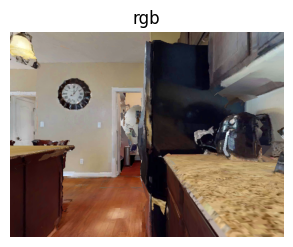

BLIP2ITMClient.cosine: (480, 640, 4), clock
Step 0: move_forward    | Similarity: 0.1605
請輸入數字喔！
action:  turn_right


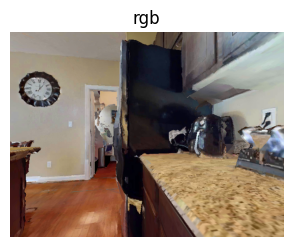

BLIP2ITMClient.cosine: (480, 640, 4), clock
Step 2: turn_right      | Similarity: 0.1698
action:  move_forward


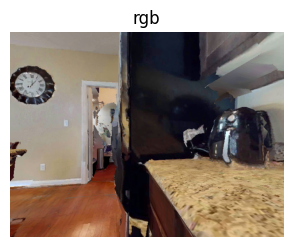

BLIP2ITMClient.cosine: (480, 640, 4), clock
Step 3: move_forward    | Similarity: 0.1665
action:  move_forward


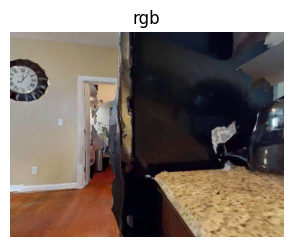

BLIP2ITMClient.cosine: (480, 640, 4), clock
Step 4: move_forward    | Similarity: 0.1927
action:  turn_left


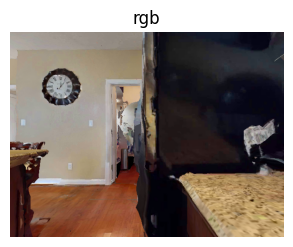

BLIP2ITMClient.cosine: (480, 640, 4), clock
Step 5: turn_left       | Similarity: 0.1907
action:  move_forward


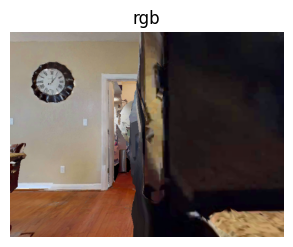

BLIP2ITMClient.cosine: (480, 640, 4), clock
Step 6: move_forward    | Similarity: 0.2208
action:  move_forward


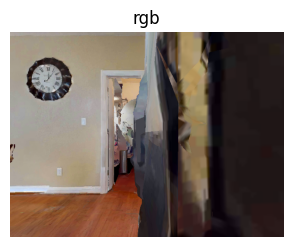

BLIP2ITMClient.cosine: (480, 640, 4), clock
Step 7: move_forward    | Similarity: 0.2944
請輸入指令喔！


In [8]:
# obtain the default, discrete actions that an agent can perform
# default action space contains 3 actions: move_forward, turn_left, and turn_right
action_names = list(cfg.agents[sim_settings["default_agent"]].action_space.keys())
print("Discrete action space: ", action_names)
print("=" * 60)
print("Testing BLIP2 with Habitat RGB Images")
print("=" * 60)
blip2_instance = None
itm = BLIP2ITMClient(port=12182)
# blip2 = get_blip2()
# search_text = "chair"
search_text = "clock"
print(f"\nSeems like there is a '{search_text}' ahead.")
print("-" * 60)

def navigateAndSee(action=""):
    if action in action_names:
        observations = sim.step(action)
        print("action: ", action)
        if display:
            display_sample(observations["color_sensor"])
        return observations["color_sensor"]

i=0
action = "move_forward"
rgb = navigateAndSee(action)
cosine_score = itm.cosine(rgb, search_text)
# similarity = blip2.get_cosine_similarity(rgb, search_text)
# print(f"Step {i}: {action:15} | Similarity: {similarity:.4f}")
print(f"Step {i}: {action:15} | Similarity: {cosine_score:.4f}")
while True:
    user_input = input("where u want to go (1: right, 2: forward, 3: left, or 'q' to quit): ")
    i=i+1
    if not user_input:  # 如果是空字串，就跳過這次循環
        print("請輸入指令喔！")
        continue
    if user_input.lower() == 'q':
        break
    try:
        action = int(user_input)
        if action == 1:
            action = "turn_right"
        elif action == 2:
            action = "move_forward"
        elif action == 3:
            action = "turn_left"
        rgb = navigateAndSee(action)
        # similarity = blip2.get_cosine_similarity(rgb, search_text)
        cosine_score = itm.cosine(rgb, search_text)
        print(f"Step {i}: {action:15} | Similarity: {cosine_score:.4f}")
        # print(f"Step {i+1}: {action:15} | Similarity: {similarity:.4f}")
    except ValueError:
        print("請輸入數字喔！")


# action = "move_backward"   // #illegal, no such action in the default action space
# navigateAndSee(action)

看自定義image觀察blip地圖

In [9]:
#!/usr/bin/env python3
"""
VLFM standalone demo:
  - 用 habitat-sim 載入 HM3D glb 場景
  - agent 從指定位置出發，直線往前走
  - 每步輸出：RGB frame、value map、frontier map、當前 cosine score
"""

import os
import math
import numpy as np
import cv2
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Habitat-Sim ──────────────────────────────────────────────────────────────
import habitat_sim
from habitat_sim.utils.common import quat_to_angle_axis, quat_from_angle_axis

# ── VLFM ─────────────────────────────────────────────────────────────────────
from depth_camera_filtering import filter_depth
from vlfm.vlm.blip2itm import BLIP2ITMClient
from vlfm.mapping.value_map import ValueMap
from vlfm.utils.geometry_utils import xyz_yaw_to_tf_matrix

# ═══════════════════════════════════════════════════════════════════════════════
# 設定（與 VLFM / HabitatMixin 相同）
# ═══════════════════════════════════════════════════════════════════════════════
SCENE_PATH    = "/home/gary/vlfm/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.glb"
START_POS     = np.array([-3.0, 0.0, 0.0])   # world space (x, height, z)
IMG_W, IMG_H  = 640, 480
HFOV_DEG      = 79.0
CAMERA_HEIGHT = 0.88    # rgb_sensor.position[1]，與 VLFM config 相同
MIN_DEPTH     = 0.5
MAX_DEPTH     = 5.0
N_STEPS       = 30
STEP_SIZE     = 0.25    # 每步 0.25m（Habitat 預設）
TEXT_PROMPT   = "Seems like there is a clock ahead."
OUTPUT_DIR    = "vlfm_demo_output"
BLIP2_PORT    = 12182

os.makedirs(OUTPUT_DIR, exist_ok=True)

# focal length（與 HabitatMixin.__init__ 相同算法）
hfov_rad = np.deg2rad(HFOV_DEG)
FX = FY = IMG_W / (2 * np.tan(hfov_rad / 2))


# ═══════════════════════════════════════════════════════════════════════════════
# 建立 Habitat-Sim
# ═══════════════════════════════════════════════════════════════════════════════
def make_sim() -> habitat_sim.Simulator:
    sim_cfg = habitat_sim.SimulatorConfiguration()
    sim_cfg.scene_id = SCENE_PATH
    sim_cfg.allow_sliding = True

    # RGB sensor
    rgb_spec = habitat_sim.CameraSensorSpec()
    rgb_spec.uuid = "rgb"
    rgb_spec.sensor_type = habitat_sim.SensorType.COLOR
    rgb_spec.resolution = [IMG_H, IMG_W]
    rgb_spec.hfov = HFOV_DEG
    rgb_spec.position = [0.0, CAMERA_HEIGHT, 0.0]

    # Depth sensor
    depth_spec = habitat_sim.CameraSensorSpec()
    depth_spec.uuid = "depth"
    depth_spec.sensor_type = habitat_sim.SensorType.DEPTH
    depth_spec.resolution = [IMG_H, IMG_W]
    depth_spec.hfov = HFOV_DEG
    depth_spec.position = [0.0, CAMERA_HEIGHT, 0.0]

    agent_cfg = habitat_sim.AgentConfiguration()
    agent_cfg.sensor_specifications = [rgb_spec, depth_spec]
    agent_cfg.action_space = {
        "move_forward": habitat_sim.ActionSpec(
            "move_forward",
            habitat_sim.ActuationSpec(amount=STEP_SIZE),
        ),
        "turn_left": habitat_sim.ActionSpec(
            "turn_left",
            habitat_sim.ActuationSpec(amount=30.0),
        ),
    }

    cfg = habitat_sim.Configuration(sim_cfg, [agent_cfg])
    sim = habitat_sim.Simulator(cfg)
    return sim


# ═══════════════════════════════════════════════════════════════════════════════
# 取得 agent 的 yaw（從 quaternion）
# ═══════════════════════════════════════════════════════════════════════════════
def get_yaw(agent_state: habitat_sim.AgentState) -> float:
    """Habitat rotation quaternion → yaw (radians, CCW from above)"""
    rot = agent_state.rotation          # np.quaternion
    angle, axis = quat_to_angle_axis(rot)
    yaw = angle * np.sign(axis[1]) if abs(axis[1]) > 0.5 else 0.0
    return float(yaw)


# ═══════════════════════════════════════════════════════════════════════════════
# 儲存每步的圖（3-panel: RGB / ValueMap / FrontierMap）
# ═══════════════════════════════════════════════════════════════════════════════
def save_frame(step, rgb, value_map, cosine_score,
               robot_xy, robot_heading, frontiers,
               sorted_frontiers, sorted_values):

    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    # ── 1. RGB ────────────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(rgb)
    ax1.set_title(f"Step {step:03d}  |  BLIP2 cosine: {cosine_score:.4f}", fontsize=11)
    ax1.axis("off")

    # ── 2. Value Map ──────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    vm_bgr = value_map.visualize()
    vm_rgb = cv2.cvtColor(vm_bgr, cv2.COLOR_BGR2RGB)
    ax2.imshow(vm_rgb)
    ax2.set_title("Value Map", fontsize=11)
    ax2.axis("off")

    # ── 3. Frontier Map（在 value map 上疊加 robot + frontiers）─────────────
    ax3 = fig.add_subplot(gs[2])
    fm_img = vm_bgr.copy()
    map_size = fm_img.shape[0]
    meters_per_pixel = 0.05   # ValueMap 預設值

    def world_to_px(xy):
        cx = cy = map_size // 2
        px = int(cx + xy[0] / meters_per_pixel)
        py = int(cy - xy[1] / meters_per_pixel)
        return (np.clip(px, 0, map_size-1), np.clip(py, 0, map_size-1))

    # robot 位置 + heading 箭頭
    rx, ry = world_to_px(robot_xy)
    cv2.circle(fm_img, (rx, ry), 8, (0, 255, 0), -1)
    arr_len = 20
    ax_end = (int(rx + arr_len * np.cos(robot_heading)),
              int(ry - arr_len * np.sin(robot_heading)))
    cv2.arrowedLine(fm_img, (rx, ry), ax_end, (0, 255, 0), 2, tipLength=0.4)

    # 所有 frontiers
    for f in frontiers:
        cv2.circle(fm_img, world_to_px(f[:2]), 5, (0, 255, 255), 2)

    # 最佳 frontier（橘色）
    if len(sorted_frontiers) > 0:
        bpt = world_to_px(sorted_frontiers[0][:2])
        cv2.circle(fm_img, bpt, 7, (0, 128, 255), -1)
        cv2.putText(fm_img, f"{sorted_values[0]:.3f}",
                    (bpt[0]+8, bpt[1]-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,128,255), 1)

    ax3.imshow(cv2.cvtColor(fm_img, cv2.COLOR_BGR2RGB))
    ax3.set_title("Frontier Map  (● robot  ○ frontier  ● best)", fontsize=10)
    ax3.axis("off")
    # 查詢 robot 當前位置的加權後 value
    curr_value = value_map.sort_waypoints(
        np.array([robot_xy]), radius=0.3
    )[1]
    curr_value_scalar = curr_value[0] if len(curr_value) > 0 else 0.0

    # 然後在標題顯示
    # 合併到 fig.suptitle，並拿掉 ax1.set_title()
    fig.suptitle(
        f"Step {step:03d}  |  "
        f"Robot: ({robot_xy[0]:.2f}, {robot_xy[1]:.2f})  |  "
        f"Yaw: {np.rad2deg(robot_heading):.1f}°  |  "
        f"Raw Cosine: {cosine_score:.4f}  |  "
        f"Map Value: {curr_value_scalar:.4f}",
        fontsize=12, y=1.02  # 稍微把 y 調高一點點，避免壓到下方的圖
    )
    out_path = os.path.join(OUTPUT_DIR, f"step_{step:03d}.png")
    plt.savefig(out_path, bbox_inches="tight", dpi=120)
    plt.close(fig)
    print(f"  → {out_path}")


# ═══════════════════════════════════════════════════════════════════════════════
# 簡易 frontier 產生器（沿前進方向 + 左右，取代 frontier_exploration lib）
# ═══════════════════════════════════════════════════════════════════════════════
def make_frontiers(robot_xy, robot_heading, n=5, spacing=1.0):
    pts = []
    for i in range(1, n + 1):
        pts.append([
            robot_xy[0] + spacing * i * np.cos(robot_heading),
            robot_xy[1] + spacing * i * np.sin(robot_heading),
        ])
    for off in [-np.pi/4, np.pi/4, -np.pi/2, np.pi/2]:
        a = robot_heading + off
        pts.append([
            robot_xy[0] + spacing * 2 * np.cos(a),
            robot_xy[1] + spacing * 2 * np.sin(a),
        ])
    return np.array(pts)


# ═══════════════════════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════════════════════
def main():
    print("=== 初始化 Habitat-Sim ===")
    sim = make_sim()
    agent = sim.initialize_agent(0)

    state = habitat_sim.AgentState()
    state.position = START_POS.copy()
    state.rotation = quat_from_angle_axis(0.0, np.array([0.0, 1.0, 0.0]))
    agent.set_state(state)

    print(f"=== 初始化 BLIP2ITM (port={BLIP2_PORT}) ===")
    itm = BLIP2ITMClient(port=BLIP2_PORT)

    print("=== 初始化 ValueMap ===")
    value_map = ValueMap(value_channels=1, use_max_confidence=False)

    print(f"=== 開始走 {N_STEPS} 步 ===")
    for step in range(N_STEPS):
        # ── observations ─────────────────────────────────────────────────────
        obs       = sim.get_sensor_observations()
        rgb       = obs["rgb"][:, :, :3].astype(np.uint8)
        depth_raw = obs["depth"].astype(np.float32)          # meters

        # depth 正規化（同 HabitatMixin）
        depth_norm     = np.clip((depth_raw - MIN_DEPTH) / (MAX_DEPTH - MIN_DEPTH), 0.0, 1.0)
        depth_filtered = filter_depth(depth_norm, blur_type=None)

        # pose（同 _cache_observations）
        cur_state = agent.get_state()
        pos = cur_state.position                   # [x, height, z]
        gps_x, gps_y = pos[0], -pos[2]            # Habitat GPS flip y
        camera_yaw   = get_yaw(cur_state)

        camera_position = np.array([gps_x, gps_y, CAMERA_HEIGHT])
        robot_xy        = camera_position[:2]
        tf_cam_to_ep    = xyz_yaw_to_tf_matrix(camera_position, camera_yaw)

        # BLIP2 cosine
        cosine_score = itm.cosine(rgb, TEXT_PROMPT)
        print(f"Step {step:03d} | pos=({gps_x:.2f},{gps_y:.2f}) "
              f"yaw={np.rad2deg(camera_yaw):.1f}° | cosine={cosine_score:.4f}")

        # 更新 ValueMap（同 _update_value_map）
        value_map.update_map(
            values=np.array([cosine_score]),
            depth=depth_filtered,
            tf_camera_to_episodic=tf_cam_to_ep,
            min_depth=MIN_DEPTH,
            max_depth=MAX_DEPTH,
            fov=hfov_rad,
        )
        value_map.update_agent_traj(robot_xy, camera_yaw)

        # frontiers + value 排序
        frontiers = make_frontiers(robot_xy, camera_yaw)
        sorted_frontiers, sorted_values = value_map.sort_waypoints(frontiers, radius=0.5)

        # 輸出圖片
        save_frame(step, rgb, value_map, cosine_score,
                   robot_xy, camera_yaw, frontiers,
                   sorted_frontiers, sorted_values)

        # 往前走
        sim.step("move_forward")

    print(f"\n完成！圖片存在 ./{OUTPUT_DIR}/")
    sim.close()

if __name__ == "__main__":
    main()


=== 初始化 Habitat-Sim ===
[23:43:34:957006]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Dataset>: Proposing JSON name : default.scene_dataset_config.json from original name : default| This file does not exist.
[23:43:34:957075]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (capsule3DSolid:capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
[23:43:34:957099]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[23:43:34:957118]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (coneSolid:coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoords_false_useTangents_false_capEnd_true) created and registered.
[23:43:34:957134]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (coneW

[23:43:34:958254]:[Assets] ResourceManager.cpp(355)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SceneInstanceAttributes-provided name : /home/gary/vlfm/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.scn  nor constructed filename : /home/gary/vlfm/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/info_semantic.json exist on disk.
[23:43:35:766679]:[Sim] Simulator.cpp(478)::instanceStageForSceneAttributes : 
---
The active scene does not contain semantic annotations : activeSemanticSceneID_ = 0  
---


  → vlfm_demo_output/step_000.png
BLIP2ITMClient.cosine: (480, 640, 3), Seems like there is a clock ahead.
Step 001 | pos=(-3.50,0.25) yaw=0.0° | cosine=0.2465
  → vlfm_demo_output/step_001.png
BLIP2ITMClient.cosine: (480, 640, 3), Seems like there is a clock ahead.
Step 002 | pos=(-3.50,0.50) yaw=0.0° | cosine=0.2605
  → vlfm_demo_output/step_002.png
BLIP2ITMClient.cosine: (480, 640, 3), Seems like there is a clock ahead.
Step 003 | pos=(-3.50,0.75) yaw=0.0° | cosine=0.2671
  → vlfm_demo_output/step_003.png
BLIP2ITMClient.cosine: (480, 640, 3), Seems like there is a clock ahead.
Step 004 | pos=(-3.50,1.00) yaw=0.0° | cosine=0.3232
  → vlfm_demo_output/step_004.png
BLIP2ITMClient.cosine: (480, 640, 3), Seems like there is a clock ahead.
Step 005 | pos=(-3.54,1.14) yaw=0.0° | cosine=0.3694
  → vlfm_demo_output/step_005.png
BLIP2ITMClient.cosine: (480, 640, 3), Seems like there is a clock ahead.
Step 006 | pos=(-3.61,1.16) yaw=0.0° | cosine=0.3191
  → vlfm_demo_output/step_006.png
BLIP2I

In [10]:
#!/usr/bin/env python3
import os
import numpy as np
import cv2
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import habitat_sim
from habitat_sim.utils.common import quat_to_angle_axis, quat_from_angle_axis

from depth_camera_filtering import filter_depth
from vlfm.vlm.blip2itm import BLIP2ITMClient
from vlfm.mapping.value_map import ValueMap
from vlfm.utils.geometry_utils import xyz_yaw_to_tf_matrix

# ═══ 設定 ═══════════════════════════════════════════════════════════════════
SCENE_PATH    = "/home/gary/vlfm/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.glb"
START_POS     = np.array([-3.0, -0.0, 0.0])
IMG_W, IMG_H  = 640, 480
HFOV_DEG      = 79.0
CAMERA_HEIGHT = 0.88
MIN_DEPTH     = 0.5
MAX_DEPTH     = 5.0
N_STEPS       = 15
STEP_SIZE     = 0.25
TEXT_PROMPT   = "Seems like there is a clock ahead."
OUTPUT_DIR    = "vlfm_demo_output"
BLIP2_PORT    = 12182

os.makedirs(OUTPUT_DIR, exist_ok=True)
hfov_rad = np.deg2rad(HFOV_DEG)
FX = FY = IMG_W / (2 * np.tan(hfov_rad / 2))

# ═══ Habitat-Sim ═════════════════════════════════════════════════════════════
def make_sim():
    sim_cfg = habitat_sim.SimulatorConfiguration()
    sim_cfg.scene_id = SCENE_PATH
    sim_cfg.allow_sliding = True

    rgb_spec = habitat_sim.CameraSensorSpec()
    rgb_spec.uuid = "rgb"
    rgb_spec.sensor_type = habitat_sim.SensorType.COLOR
    rgb_spec.resolution = [IMG_H, IMG_W]
    rgb_spec.hfov = HFOV_DEG
    rgb_spec.position = [0.0, CAMERA_HEIGHT, 0.0]

    depth_spec = habitat_sim.CameraSensorSpec()
    depth_spec.uuid = "depth"
    depth_spec.sensor_type = habitat_sim.SensorType.DEPTH
    depth_spec.resolution = [IMG_H, IMG_W]
    depth_spec.hfov = HFOV_DEG
    depth_spec.position = [0.0, CAMERA_HEIGHT, 0.0]

    agent_cfg = habitat_sim.AgentConfiguration()
    agent_cfg.sensor_specifications = [rgb_spec, depth_spec]
    agent_cfg.action_space = {
        "move_forward": habitat_sim.ActionSpec(
            "move_forward", habitat_sim.ActuationSpec(amount=STEP_SIZE)),
        "turn_left": habitat_sim.ActionSpec(
            "turn_left", habitat_sim.ActuationSpec(amount=30.0)),
    }
    return habitat_sim.Simulator(habitat_sim.Configuration(sim_cfg, [agent_cfg]))

def get_yaw(agent_state):
    rot = agent_state.rotation
    angle, axis = quat_to_angle_axis(rot)
    return float(angle * np.sign(axis[1]) if abs(axis[1]) > 0.5 else 0.0)

# ═══ 重疊像素分析（新增）════════════════════════════════════════════════════
def print_overlap_analysis(value_map: ValueMap, conf_before: np.ndarray,
                           conf_after: np.ndarray, step: int):
    """
    比較 update_map 前後的信心矩陣，找出：
      1. 本步新觀測到的像素（conf_before==0, conf_after>0）
      2. 重疊像素（conf_before>0 AND conf_after>0）
         → 信心變高 or 變低，並換算回 world XY 座標
    ValueMap 座標系：
      px = int(cam_x * ppm) + origin[0]    (行，對應 x)
      py = int(-cam_y * ppm) + origin[1]   (列，對應 y)
    → world_x = (px - origin[0]) / ppm
    → world_y = -(py - origin[1]) / ppm
    """
    ppm    = value_map.pixels_per_meter           # 預設 20 px/m
    origin = value_map._episode_pixel_origin      # (ox, oy)
    size   = conf_before.shape[0]

    diff = conf_after - conf_before               # 正：信心上升，負：下降

    # 新觀測（之前是 0，現在有值）
    new_mask      = (conf_before == 0) & (conf_after > 0)
    # 重疊且信心上升
    overlap_up    = (conf_before > 0) & (diff > 1e-4)
    # 重疊且信心下降
    overlap_down  = (conf_before > 0) & (diff < -1e-4)

    def px_to_world(rows, cols):
        """rows/cols → world (x, y) in meters"""
        # ValueMap 存的 row=px (x方向), col=py (y方向)
        wx =  (rows - origin[0]) / ppm
        wy = -(cols - origin[1]) / ppm
        return wx, wy

    n_new  = np.sum(new_mask)
    n_up   = np.sum(overlap_up)
    n_down = np.sum(overlap_down)

    print(f"\n{'='*60}")
    print(f"[Step {step:03d}] 重疊分析：")
    print(f"  新觀測像素：{n_new} px  ({n_new/ppm**2:.2f} m²)")
    print(f"  重疊像素（信心↑）：{n_up} px")
    print(f"  重疊像素（信心↓）：{n_down} px")

    # 信心變化最大的前 5 個重疊像素，印出 world XY
    all_overlap = (conf_before > 0) & (conf_after > 0)
    if np.any(all_overlap):
        rows_ov, cols_ov = np.where(all_overlap)
        diffs_ov = diff[rows_ov, cols_ov]
        conf_b   = conf_before[rows_ov, cols_ov]
        conf_a   = conf_after[rows_ov, cols_ov]

        # 按 |diff| 降序取前5
        top_idx = np.argsort(-np.abs(diffs_ov))[:5]
        print(f"  前5大信心變化像素（world XY）：")
        for i in top_idx:
            wx, wy = px_to_world(rows_ov[i], cols_ov[i])
            direction = "↑" if diffs_ov[i] > 0 else "↓"
            print(f"    ({wx:+.2f}m, {wy:+.2f}m)  "
                  f"conf: {conf_b[i]:.3f} → {conf_a[i]:.3f}  "
                  f"Δ={diffs_ov[i]:+.4f} {direction}")

        # 統計信心上升 vs 下降的平均 Δ
        if n_up > 0:
            mean_up = diffs_ov[diffs_ov > 1e-4].mean()
            print(f"  重疊像素平均信心↑：+{mean_up:.4f}")
        if n_down > 0:
            mean_down = diffs_ov[diffs_ov < -1e-4].mean()
            print(f"  重疊像素平均信心↓：{mean_down:.4f}")
    print(f"{'='*60}")

# ═══ 存圖 ════════════════════════════════════════════════════════════════════
def save_frame(step, rgb, value_map, cosine_score,
               robot_xy, robot_heading, frontiers,
               sorted_frontiers, sorted_values):

    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(rgb)
    ax1.axis("off")

    ax2 = fig.add_subplot(gs[1])
    vm_bgr = value_map.visualize()
    ax2.imshow(cv2.cvtColor(vm_bgr, cv2.COLOR_BGR2RGB))
    ax2.set_title("Value Map", fontsize=11)
    ax2.axis("off")

    ax3 = fig.add_subplot(gs[2])
    fm_img = vm_bgr.copy()
    map_size = fm_img.shape[0]
    mpp = 0.05

    def world_to_px(xy):
        cx = cy = map_size // 2
        return (np.clip(int(cx + xy[0]/mpp), 0, map_size-1),
                np.clip(int(cy - xy[1]/mpp), 0, map_size-1))

    rx, ry = world_to_px(robot_xy)
    cv2.circle(fm_img, (rx, ry), 8, (0, 255, 0), -1)
    ax_end = (int(rx + 20*np.cos(robot_heading)),
              int(ry - 20*np.sin(robot_heading)))
    cv2.arrowedLine(fm_img, (rx, ry), ax_end, (0,255,0), 2, tipLength=0.4)
    for f in frontiers:
        cv2.circle(fm_img, world_to_px(f[:2]), 5, (0,255,255), 2)
    if len(sorted_frontiers) > 0:
        bpt = world_to_px(sorted_frontiers[0][:2])
        cv2.circle(fm_img, bpt, 7, (0,128,255), -1)
        cv2.putText(fm_img, f"{sorted_values[0]:.3f}", (bpt[0]+8, bpt[1]-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,128,255), 1)

    ax3.imshow(cv2.cvtColor(fm_img, cv2.COLOR_BGR2RGB))
    ax3.set_title("Frontier Map  (● robot  ○ frontier  ● best)", fontsize=10)
    ax3.axis("off")

    curr_value = value_map.sort_waypoints(np.array([robot_xy]), radius=0.3)[1]
    curr_value_scalar = curr_value[0] if len(curr_value) > 0 else 0.0

    fig.suptitle(
        f"Step {step:03d}  |  "
        f"Robot: ({robot_xy[0]:.2f}, {robot_xy[1]:.2f})  |  "
        f"Yaw: {np.rad2deg(robot_heading):.1f}°  |  "
        f"Raw Cosine: {cosine_score:.4f}  |  "
        f"Map Value: {curr_value_scalar:.4f}",
        fontsize=12, y=1.02
    )
    out_path = os.path.join(OUTPUT_DIR, f"step_{step:03d}.png")
    plt.savefig(out_path, bbox_inches="tight", dpi=120)
    plt.close(fig)
    print(f"  → {out_path}")

# ═══ frontier 產生器 ═════════════════════════════════════════════════════════
def make_frontiers(robot_xy, robot_heading, n=5, spacing=1.0):
    pts = []
    for i in range(1, n+1):
        pts.append([robot_xy[0] + spacing*i*np.cos(robot_heading),
                    robot_xy[1] + spacing*i*np.sin(robot_heading)])
    for off in [-np.pi/4, np.pi/4, -np.pi/2, np.pi/2]:
        a = robot_heading + off
        pts.append([robot_xy[0] + spacing*2*np.cos(a),
                    robot_xy[1] + spacing*2*np.sin(a)])
    return np.array(pts)

# ═══ MAIN ════════════════════════════════════════════════════════════════════
def main():
    print("=== 初始化 Habitat-Sim ===")
    sim   = make_sim()
    agent = sim.initialize_agent(0)
    state = habitat_sim.AgentState()
    state.position = START_POS.copy()
    state.rotation = quat_from_angle_axis(0.0, np.array([0.0, 1.0, 0.0]))
    agent.set_state(state)

    print(f"=== 初始化 BLIP2ITM (port={BLIP2_PORT}) ===")
    itm = BLIP2ITMClient(port=BLIP2_PORT)

    print("=== 初始化 ValueMap ===")
    value_map = ValueMap(value_channels=1, use_max_confidence=False)

    print(f"=== 開始走 {N_STEPS} 步 ===")
    for step in range(N_STEPS):
        obs       = sim.get_sensor_observations()
        rgb       = obs["rgb"][:, :, :3].astype(np.uint8)
        depth_raw = obs["depth"].astype(np.float32)

        depth_norm     = np.clip((depth_raw - MIN_DEPTH) / (MAX_DEPTH - MIN_DEPTH), 0.0, 1.0)
        depth_filtered = filter_depth(depth_norm, blur_type=None)

        cur_state = agent.get_state()
        pos = cur_state.position
        gps_x, gps_y = pos[0], -pos[2]
        camera_yaw   = get_yaw(cur_state)

        camera_position = np.array([gps_x, gps_y, CAMERA_HEIGHT])
        robot_xy        = camera_position[:2]
        tf_cam_to_ep    = xyz_yaw_to_tf_matrix(camera_position, camera_yaw)

        cosine_score = itm.cosine(rgb, TEXT_PROMPT)
        print(f"Step {step:03d} | pos=({gps_x:.2f},{gps_y:.2f}) "
              f"yaw={np.rad2deg(camera_yaw):.1f}° | cosine={cosine_score:.4f}")

        # ── 重疊分析：update_map 前後快照 ──────────────────────────────────
        conf_before = value_map._map.copy()   # update_map 之前的信心矩陣

        value_map.update_map(
            values=np.array([cosine_score]),
            depth=depth_filtered,
            tf_camera_to_episodic=tf_cam_to_ep,
            min_depth=MIN_DEPTH,
            max_depth=MAX_DEPTH,
            fov=hfov_rad,
        )

        conf_after = value_map._map.copy()    # update_map 之後的信心矩陣

        # 印出重疊像素分析
        print_overlap_analysis(value_map, conf_before, conf_after, step)
        # ────────────────────────────────────────────────────────────────────

        value_map.update_agent_traj(robot_xy, camera_yaw)

        frontiers = make_frontiers(robot_xy, camera_yaw)
        sorted_frontiers, sorted_values = value_map.sort_waypoints(frontiers, radius=0.5)

        save_frame(step, rgb, value_map, cosine_score,
                   robot_xy, camera_yaw, frontiers,
                   sorted_frontiers, sorted_values)

        sim.step("move_forward")

    print(f"\n完成！圖片存在 ./{OUTPUT_DIR}/")
    sim.close()

if __name__ == "__main__":
    main()

=== 初始化 Habitat-Sim ===
[23:43:46:887747]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Dataset>: Proposing JSON name : default.scene_dataset_config.json from original name : default| This file does not exist.
[23:43:46:887807]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (capsule3DSolid:capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
[23:43:46:887827]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[23:43:46:887841]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (coneSolid:coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoords_false_useTangents_false_capEnd_true) created and registered.
[23:43:46:887853]:[Metadata] AssetAttributesManager.cpp(123)::createObject : Asset attributes (coneW

[23:43:46:888854]:[Assets] ResourceManager.cpp(355)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SceneInstanceAttributes-provided name : /home/gary/vlfm/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.scn  nor constructed filename : /home/gary/vlfm/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/info_semantic.json exist on disk.
[23:43:47:598845]:[Sim] Simulator.cpp(478)::instanceStageForSceneAttributes : 
---
The active scene does not contain semantic annotations : activeSemanticSceneID_ = 0  
---


  → vlfm_demo_output/step_000.png
BLIP2ITMClient.cosine: (480, 640, 3), Seems like there is a clock ahead.
Step 001 | pos=(-3.50,0.25) yaw=0.0° | cosine=0.2465

[Step 001] 重疊分析：
  新觀測像素：1235 px  (3.09 m²)
  重疊像素（信心↑）：1000 px
  重疊像素（信心↓）：52 px
  前5大信心變化像素（world XY）：
    (-2.70m, +0.25m)  conf: 0.250 → 0.850  Δ=+0.5999 ↑
    (-2.65m, +0.30m)  conf: 0.251 → 0.836  Δ=+0.5843 ↑
    (-2.75m, +0.20m)  conf: 0.251 → 0.832  Δ=+0.5809 ↑
    (-2.60m, +0.30m)  conf: 0.258 → 0.836  Δ=+0.5774 ↑
    (-2.65m, +0.25m)  conf: 0.268 → 0.845  Δ=+0.5767 ↑
  重疊像素平均信心↑：+0.1514
  重疊像素平均信心↓：-0.0841
  → vlfm_demo_output/step_001.png
BLIP2ITMClient.cosine: (480, 640, 3), Seems like there is a clock ahead.
Step 002 | pos=(-3.50,0.50) yaw=0.0° | cosine=0.2605

[Step 002] 重疊分析：
  新觀測像素：467 px  (1.17 m²)
  重疊像素（信心↑）：1464 px
  重疊像素（信心↓）：36 px
  前5大信心變化像素（world XY）：
    (-3.15m, +0.50m)  conf: 0.250 → 0.850  Δ=+0.5999 ↑
    (-3.10m, +0.50m)  conf: 0.268 → 0.845  Δ=+0.5767 ↑
    (-3.05m, +0.55m)  conf: 0.258 → 0.794  Δ

同張影像不同提示詞的相似度

In [11]:
import torch
import requests
from PIL import Image
import matplotlib.pyplot as plt
from lavis.models import load_model_and_preprocess

# ── 1. 設定裝置 ──────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── 2. 載入模型與前處理器 ─────────────────────────────────
# model_type 可選 "pretrain" 或 "coco"
model, vis_processors, text_processors = load_model_and_preprocess(
    name="blip2_image_text_matching",
    model_type="pretrain",
    is_eval=True,
    device=device,
)
model.tokenizer.padding_side = "right"
# Monkey-patch：讓 __call__ 預設帶 padding=True, truncation=True
_orig_tokenize = model.tokenizer.__class__.__call__

def _patched_tokenize(self, *args, **kwargs):
    kwargs.setdefault("padding", True)
    kwargs.setdefault("truncation", True)
    return _orig_tokenize(self, *args, **kwargs)

import types
model.tokenizer.__call__ = types.MethodType(_patched_tokenize, model.tokenizer)

# ── 3. 載入圖片 ──────────────────────────────────────────
raw_image = Image.open("/home/gary/try/flag.png").convert("RGB")
# ── 4. 前處理圖片與文字 ──────────────────────────────────
image = vis_processors["eval"](raw_image).unsqueeze(0).to(device)  # (1, C, H, W)

captions = [
    "Seems like there is a 'car' ahead.",
    "Seems like there is a 'waterpool' ahead.",
    "Seems like there is a 'table' ahead.",
   
]

# ── 5a. ITM 模式（Image-Text Matching）─────────────────
# 輸出 logits，softmax 後 index=1 為「匹配」的機率
print("=== ITM Scores ===")
with torch.no_grad():
    for caption in captions:
        txt = text_processors["eval"](caption)
        itm_output = model(
            {"image": image, "text_input": [txt]},
            match_head="itm"
        )
        itm_scores = torch.nn.functional.softmax(itm_output, dim=1)
        prob = itm_scores[:, 1].item()
        print(f"  [{prob:.3%}] {caption}")

# ── 5b. ITC 模式（Image-Text Contrastive Similarity）────
# 輸出 cosine similarity，值越高代表越相似
print("\n=== ITC Scores ===")
with torch.no_grad():
    for caption in captions:
        txt = text_processors["eval"](caption)
        itc_score = model(
            {"image": image, "text_input": [txt]},
            match_head="itc"
        )
        print(f"  [similarity={itc_score.item():.4f}] {caption}")
        
plt.imshow(raw_image)
plt.axis('off')
plt.show()

Using device: cuda


/home/gary/miniconda3/envs/vlfm_3.9/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/gary/miniconda3/envs/vlfm_3.9/lib/python3.9/site-packages/lavis/models/eva_vit.py:433: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  state_dict = torch.load(cached_file, map_location="cpu")
/home/gary/miniconda3/envs/vlfm_3.9/lib/python3.9/site-packages/lavis/models/blip2_models/blip2.py:85: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(cached_file, map_location="cpu")


OutOfMemoryError: CUDA out of memory. Tried to allocate 18.00 MiB. GPU 0 has a total capacity of 7.50 GiB of which 43.38 MiB is free. Process 1924046 has 92.91 MiB memory in use. Process 3693101 has 212.00 MiB memory in use. Process 3693104 has 2.95 GiB memory in use. Process 3693102 has 830.00 MiB memory in use. Including non-PyTorch memory, this process has 1.49 GiB memory in use. Of the allocated memory 889.79 MiB is allocated by PyTorch, and 68.21 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
test_scene = "/home/gary/vlfm/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.glb"

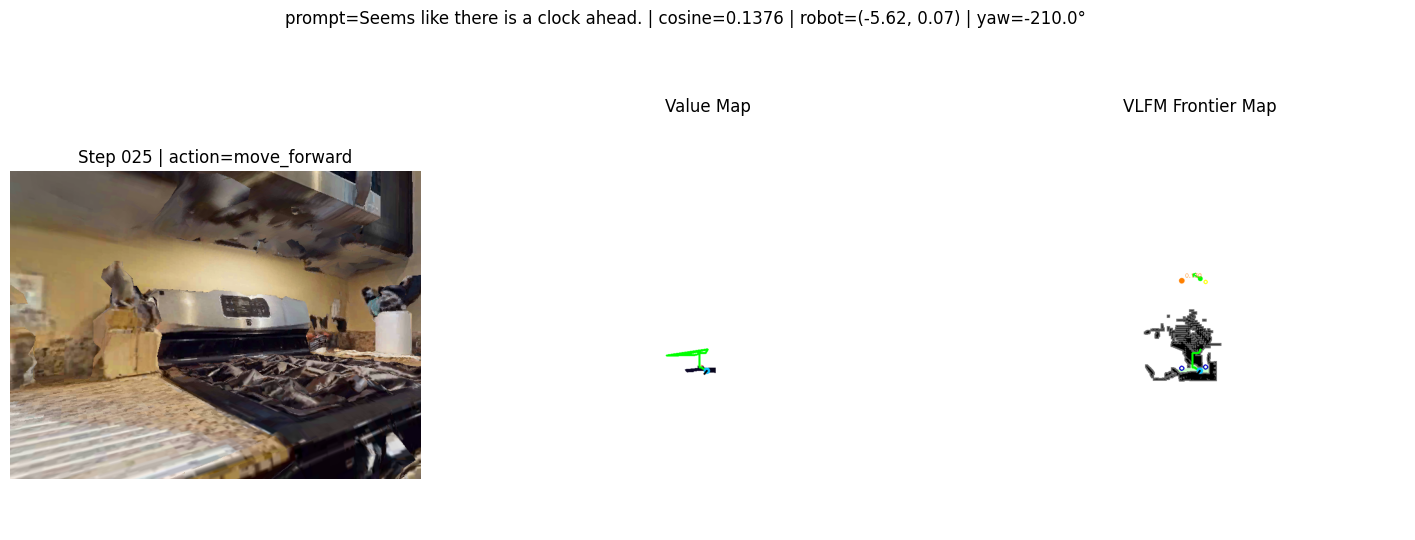

Controls: w=forward, s=backward, a=turn_left, d=turn_right, q=quit
Please press one of: w/a/s/d/q


In [12]:
exec(open("try0428_wasd_vlfm.py").read())